# 02 — Clasificación y análisis con LLM (Ollama)

Clasifica una muestra estratificada de mensajes Conti usando `qwen2.5:14b` local.  
Produce:
- `data/processed/conti_sample_classified.parquet` — muestra con columna `category`
- `data/processed/actor_profiles.json` — perfil de rol inferido por actor


## 0. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('src').resolve()))

import json
import time
import pandas as pd
import ollama
from tqdm.auto import tqdm

PROCESSED_DIR   = Path('../data/processed')
PARQUET_IN      = PROCESSED_DIR / 'conti_unified.parquet'
PARQUET_OUT     = PROCESSED_DIR / 'conti_sample_classified.parquet'
PROFILES_OUT    = PROCESSED_DIR / 'actor_profiles.json'
CHECKPOINT_PATH = PROCESSED_DIR / 'checkpoint_classified.parquet'

MODEL = 'qwen2.5:14b'
# OJO, SI NO SE TIENE HAY QUE BAJARLO ANTES: 
# ollama pull nomic-embed-text-v2-moe
#MODEL = 'nomic-embed-text-v2-moe'

assert PARQUET_IN.exists(), f'No se encuentra {PARQUET_IN} — ejecuta primero el notebook 01'
print('Dependencias OK')

Dependencias OK


/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cargar dataset unificado

In [2]:
df = pd.read_parquet(PARQUET_IN)

print(f'Mensajes totales : {len(df):,}')
print(f'Actores únicos   : {df.username.nunique()}')
print(f'Rango temporal   : {df.timestamp.min().date()} → {df.timestamp.max().date()}')
print(f'\nColumnas: {list(df.columns)}')

Mensajes totales : 216,303
Actores únicos   : 485
Rango temporal   : 2020-06-21 → 2022-02-28

Columnas: ['timestamp', 'username', 'to_user', 'message', 'source', 'channel', 'lang']


## 2. Muestreo estratificado por actor

Top 30 actores por volumen × 50 mensajes cada uno = ~1 500 mensajes.  
Muestra distribuida uniformemente en el tiempo (no solo mensajes recientes).

In [3]:
TOP_N_ACTORS   = 30
MSGS_PER_ACTOR = 50

top_actors = (
    df.groupby('username').size()
    .sort_values(ascending=False)
    .head(TOP_N_ACTORS)
    .index.tolist()
)

def sample_actor(actor_df: pd.DataFrame, n: int) -> pd.DataFrame:
    """Muestra uniforme en el tiempo: divide en n bloques, toma 1 de cada uno."""
    actor_df = actor_df.sort_values('timestamp').reset_index(drop=True)
    if len(actor_df) <= n:
        return actor_df
    indices = [int(i * len(actor_df) / n) for i in range(n)]
    return actor_df.iloc[indices]

frames = []
for actor in top_actors:
    actor_msgs = df[df['username'] == actor]
    frames.append(sample_actor(actor_msgs, MSGS_PER_ACTOR))

sample = pd.concat(frames, ignore_index=True)
sample = sample.sort_values('timestamp').reset_index(drop=True)

print(f'Muestra total: {len(sample):,} mensajes de {sample.username.nunique()} actores')
print('\nMensajes por actor:')
print(sample.groupby('username').size().sort_values(ascending=False).to_string())

Muestra total: 1,500 mensajes de 30 actores

Mensajes por actor:
username
angelo       50
baget        50
bentley      50
bio          50
bloodrush    50
braun        50
defender     50
deploy       50
driver       50
hof          50
kaktus       50
mango        50
marsel       50
mors         50
mushroom     50
price        50
professor    50
revers       50
stern        50
strix        50
target       50
tl1          50
tl2          50
tramp        50
ttrr         50
user4        50
user7        50
user8        50
user9        50
veron        50


## 3. Clasificación de mensajes con qwen2.5:14b

Categorías:
| Categoría | Descripción |
|---|---|
| `technical` | Desarrollo de malware, builds, código, infraestructura |
| `operational` | Ataques, targets, accesos, despliegue |
| `financial` | Pagos, bitcoin, ransom, negociaciones |
| `organizational` | Gestión, tareas, asignaciones, RRHH |
| `comms` | Comunicación general, saludos, off-topic |
| `unknown` | No clasificable (muy corto, sin contexto) |

In [4]:
CATEGORIES = {'technical', 'operational', 'financial', 'organizational', 'comms', 'unknown'}

SYSTEM_PROMPT = """You are a threat intelligence analyst classifying messages from the leaked Conti ransomware group chats.
Messages are mostly in Russian. Classify each message into exactly one category:
- technical: malware development, builds, code, infrastructure, bugs, tools
- operational: attacks, targets, victims, accesses, deployment, reconnaissance
- financial: payments, bitcoin, ransom negotiations, money, commissions
- organizational: management, task assignments, team structure, HR, recruitment
- comms: general conversation, greetings, scheduling, off-topic
- unknown: too short or ambiguous to classify

Reply with ONLY the category name, nothing else."""

def classify_message(text: str) -> str:
    if len(text.strip()) < 5:
        return 'unknown'
    try:
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': f'Message: {text[:400]}'}
            ],
            options={'temperature': 0, 'num_predict': 10}
        )
        raw = resp.message.content.strip().lower().split()[0].rstrip('.,:')
        return raw if raw in CATEGORIES else 'unknown'
    except Exception:
        return 'unknown'

print('Función de clasificación lista. Ejemplo:')
test = classify_message('Нужно собрать новый билд для x64')
print(f'  "Нужно собрать новый билд для x64" → {test}')

Función de clasificación lista. Ejemplo:
  "Нужно собрать новый билд для x64" → technical


In [5]:
# Retomar desde checkpoint si existe
if CHECKPOINT_PATH.exists():
    done = pd.read_parquet(CHECKPOINT_PATH)
    done_ids = set(done.index)
    print(f'Checkpoint encontrado: {len(done):,} mensajes ya clasificados')
else:
    done = pd.DataFrame()
    done_ids = set()
    print('Sin checkpoint previo — comenzando desde cero')

todo = sample[~sample.index.isin(done_ids)].copy()
print(f'Pendientes: {len(todo):,} mensajes')

Sin checkpoint previo — comenzando desde cero
Pendientes: 1,500 mensajes


In [6]:
CHECKPOINT_EVERY = 50  # guardar progreso cada N mensajes

results = []
t0 = time.time()

for i, (idx, row) in enumerate(tqdm(todo.iterrows(), total=len(todo), desc='Clasificando')):
    cat = classify_message(row['message'])
    results.append({'idx': idx, 'category': cat})

    if (i + 1) % CHECKPOINT_EVERY == 0:
        chunk = pd.DataFrame(results).set_index('idx')
        partial = pd.concat([done, sample.loc[chunk.index].assign(category=chunk['category'])])
        partial.to_parquet(CHECKPOINT_PATH)

elapsed = time.time() - t0
print(f'\nClasificación completada en {elapsed/60:.1f} min ({elapsed/max(len(todo),1):.1f} s/msg)')

# Combinar con checkpoint
new_df = pd.DataFrame(results).set_index('idx')
sample_new = sample.loc[new_df.index].copy()
sample_new['category'] = new_df['category'].values

classified = pd.concat([done, sample_new]).sort_values('timestamp').reset_index(drop=True)
print(f'Total clasificados: {len(classified):,}')

Clasificando: 100%|██████████████████████████████████████████████████████████████████████| 1500/1500 [03:04<00:00,  8.11it/s]


Clasificación completada en 3.1 min (0.1 s/msg)
Total clasificados: 1,500


## 4. Análisis de resultados

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print('=== Distribución global de categorías ===')
cat_counts = classified['category'].value_counts()
print(cat_counts.to_string())
print(f'\n{(cat_counts / len(classified) * 100).round(1).to_string()} %')

=== Distribución global de categorías ===
category
comms             523
technical         516
unknown           225
operational       141
financial          59
organizational     36

category
comms             34.9
technical         34.4
unknown           15.0
operational        9.4
financial          3.9
organizational     2.4 %


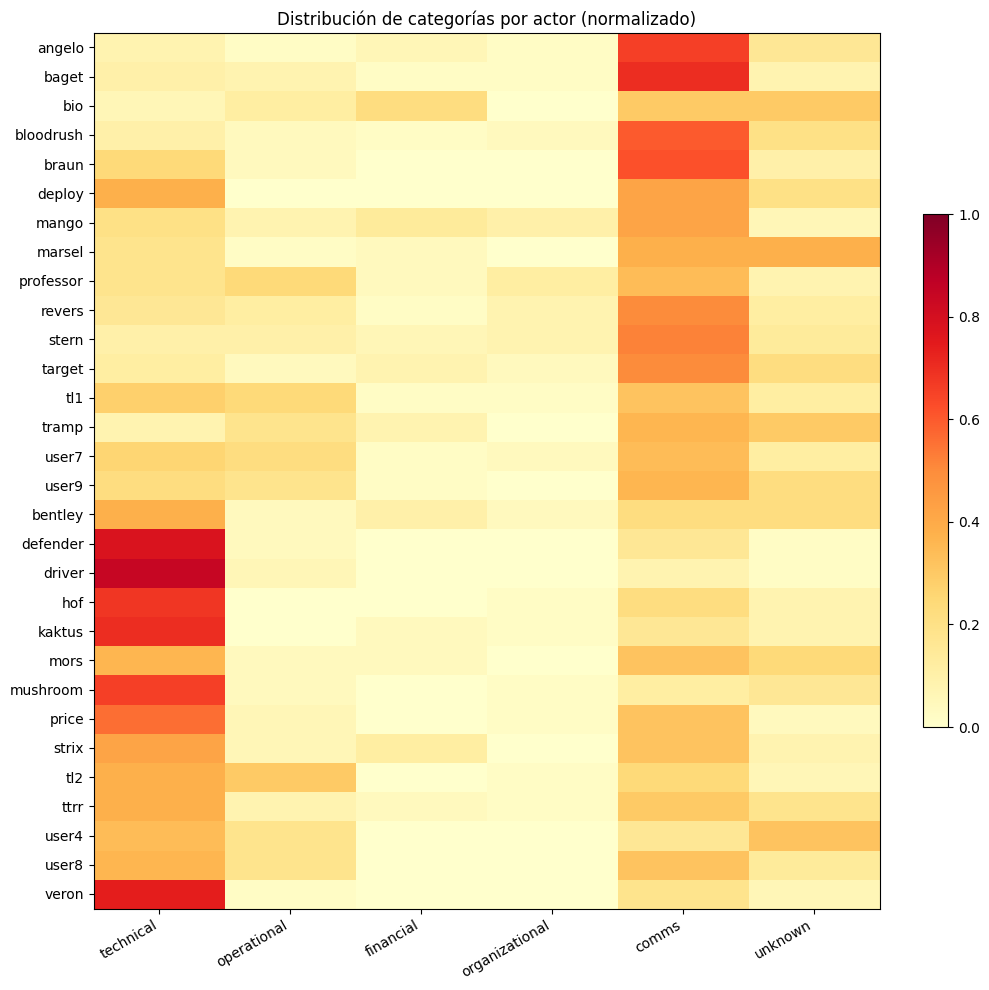

In [8]:
# Heatmap: actor × categoría (normalizado por actor)
pivot = (
    classified.groupby(['username', 'category']).size()
    .unstack(fill_value=0)
)
# Ordenar por categoría dominante
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

cat_order = ['technical', 'operational', 'financial', 'organizational', 'comms', 'unknown']
cat_order = [c for c in cat_order if c in pivot_norm.columns]
pivot_norm = pivot_norm[cat_order]

# Ordenar actores por su categoría principal
pivot_norm = pivot_norm.loc[pivot_norm.idxmax(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(pivot_norm.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(cat_order)))
ax.set_xticklabels(cat_order, rotation=30, ha='right')
ax.set_yticks(range(len(pivot_norm)))
ax.set_yticklabels(pivot_norm.index)
ax.set_title('Distribución de categorías por actor (normalizado)')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

In [9]:
# Top mensajes por categoría (ejemplos)
for cat in cat_order[:-1]:  # excluir 'unknown'
    examples = classified[classified['category'] == cat]['message'].sample(
        min(3, (classified['category'] == cat).sum()), random_state=42
    ).tolist()
    print(f'\n=== {cat.upper()} ===')
    for ex in examples:
        print(f'  • {ex[:120]}')


=== TECHNICAL ===
  • а то эта хрень что то не то

```
Serial Number: W8KMJ24BNHCR6CM


Website Link: https://home.mcafee.com/secure/protected
  • [Ошибка: сообщение зашифровано, и невозможно его расшифровать.]
  • [Ошибка: сообщение зашифровано, и невозможно его расшифровать.]

=== OPERATIONAL ===
  • После фалов mors каждый день
  • чуть вылезли из пользовательского сегмента серверов
нашел сервер с сессией ДА, но она там еще с августа висит и пароль у
  • дашь добро - задолбим их директоров и руководителей

=== FINANCIAL ===
  • 3MRynF2B2NUdxG3ESbuJ1h5JKG6pLSthQN
  • за 6к или сколько там
  • так уже пора внести

=== ORGANIZATIONAL ===
  • меня интересует что будет дальше, чере год два ?
  • я ввожу в курс дела

ну а если "предлагаю" - то предлагаю подгрузить что-нибудь в работу без БК
если нет - надо думать к
  • Привет. Как дела? 
какие результаты у тебя? 
Какие задачи стоят?
Какие идеи есть что можно добавить и улучшить?

=== COMMS ===
  • но не передавить бы
  • ну а какой выход

## 5. Perfilado de actores

Para cada top actor: enviamos un lote de sus mensajes clasificados y pedimos al LLM que infiera su rol en la organización.

In [10]:
PROFILE_SYSTEM = """You are a threat intelligence analyst studying the Conti ransomware group.
Given a sample of messages from one member, infer their role in the organization.

Reply in JSON with these fields:
{
  "role": "<one of: leader, developer, operator, negotiator, affiliate, support, unknown>",
  "confidence": "<high|medium|low>",
  "summary": "<2-3 sentences in English describing their responsibilities>",
  "evidence": ["<quote or paraphrase from messages, max 3>"]
}"""

def profile_actor(actor: str, messages: list[str]) -> dict:
    msg_block = '\n'.join(f'- {m[:200]}' for m in messages[:30])
    user_msg  = f'Actor: {actor}\n\nMessages:\n{msg_block}'
    try:
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': PROFILE_SYSTEM},
                {'role': 'user',   'content': user_msg}
            ],
            options={'temperature': 0.1, 'num_predict': 300}
        )
        raw = resp.message.content.strip()
        # Extraer JSON aunque haya texto alrededor
        start = raw.find('{')
        end   = raw.rfind('}') + 1
        return json.loads(raw[start:end])
    except Exception as e:
        return {'role': 'unknown', 'confidence': 'low', 'summary': str(e), 'evidence': []}

print('Función de perfilado lista. Probando con un actor...')
test_actor = top_actors[0]
test_msgs  = classified[classified['username'] == test_actor]['message'].tolist()
test_profile = profile_actor(test_actor, test_msgs)
print(f'\nActor: {test_actor}')
print(json.dumps(test_profile, indent=2, ensure_ascii=False))

Función de perfilado lista. Probando con un actor...

Actor: target
{
  "role": "operator",
  "confidence": "medium",
  "summary": "The individual appears to be an operator involved in the execution of tasks related to ransomware operations, such as deploying malware and communicating with affiliates or victims. They seem to work under supervision and are responsible for executing orders from a supervisor.",
  "evidence": [
    "параллельно выполняющая заказы от своего куратора",
    "да на текущий залей",
    "мы заканчиваем работу"
  ]
}


In [11]:
actor_profiles = {}

for actor in tqdm(top_actors, desc='Perfilando actores'):
    msgs = classified[classified['username'] == actor]['message'].tolist()
    actor_profiles[actor] = profile_actor(actor, msgs)

# Mostrar resumen
print('\n=== ROLES INFERIDOS ===')
for actor, profile in actor_profiles.items():
    role = profile.get('role', '?')
    conf = profile.get('confidence', '?')
    summ = profile.get('summary', '')[:80]
    print(f'  {actor:<15} [{role:<15}] ({conf:<6}) — {summ}')

Perfilando actores: 100%|████████████████████████████████████████████████████████████████████| 30/30 [01:58<00:00,  3.94s/it]


=== ROLES INFERIDOS ===
  target          [operator       ] (medium) — This individual appears to be an operator within the Conti ransomware group, res
  bentley         [operator       ] (high  ) — The individual appears to be an operator responsible for deploying and testing r
  tl1             [operator       ] (high  ) — This individual appears to be an operator within the Conti ransomware group, res
  stern           [operator       ] (medium) — The individual appears to be an operator involved in managing the ransomware dep
  defender        [support        ] (high  ) — This individual appears to be a support member responsible for maintaining commu
  hof             [developer      ] (high  ) — This individual appears to be a developer within the Conti ransomware group, res
  user8           [operator       ] (high  ) — The individual is actively involved in the technical operations of Conti, includ
  mango           [operator       ] (high  ) — The individual appears to be an 

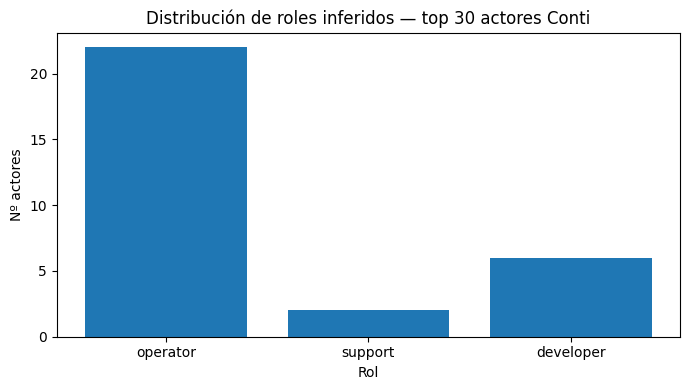

In [12]:
# Distribución de roles
from collections import Counter

roles = [p.get('role', 'unknown') for p in actor_profiles.values()]
role_counts = Counter(roles)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(role_counts.keys(), role_counts.values())
ax.set_title('Distribución de roles inferidos — top 30 actores Conti')
ax.set_ylabel('Nº actores')
ax.set_xlabel('Rol')
plt.tight_layout()
plt.show()

## 6. Guardar

In [13]:
classified.to_parquet(PARQUET_OUT, index=False)
print(f'Muestra clasificada → {PARQUET_OUT}  ({PARQUET_OUT.stat().st_size/1024:.0f} KB)')

with open(PROFILES_OUT, 'w', encoding='utf-8') as f:
    json.dump(actor_profiles, f, indent=2, ensure_ascii=False)
print(f'Perfiles de actores → {PROFILES_OUT}')

# Limpiar checkpoint
if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()
    print('Checkpoint eliminado')

print('\n=== RESUMEN FINAL ===')
print(f'  Mensajes clasificados : {len(classified):,}')
print(f'  Actores perfilados    : {len(actor_profiles)}')
print(f'  Categorías            : {classified["category"].value_counts().to_dict()}')

Muestra clasificada → ../data/processed/conti_sample_classified.parquet  (87 KB)
Perfiles de actores → ../data/processed/actor_profiles.json
Checkpoint eliminado

=== RESUMEN FINAL ===
  Mensajes clasificados : 1,500
  Actores perfilados    : 30
  Categorías            : {'comms': 523, 'technical': 516, 'unknown': 225, 'operational': 141, 'financial': 59, 'organizational': 36}
